<a href="https://www.kaggle.com/code/kedhareswernaidu/moonknight?scriptVersionId=229081119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Like Paintings

Visualizing sample Monet paintings:


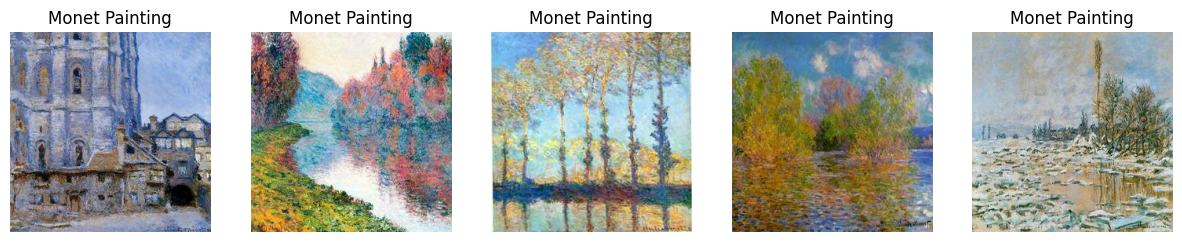

Visualizing sample Photographs:


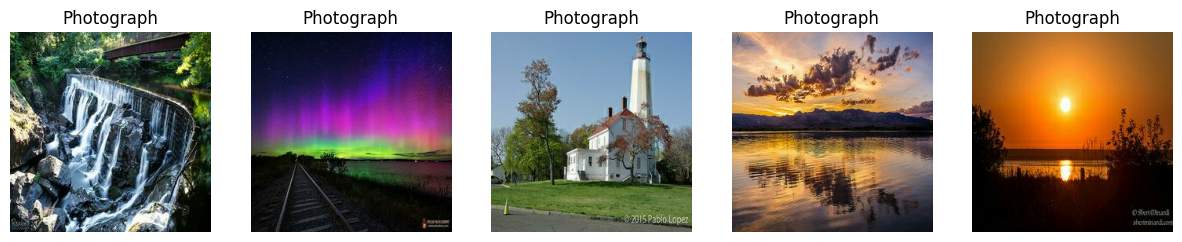

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

monet_jpg_dir = "/kaggle/input/c/gan-getting-started/monet_jpg"  
photo_jpg_dir = "/kaggle/input/c/gan-getting-started/photo_jpg" 

# Function to load and preprocess an image
def load_and_preprocess_image(filename, img_size=(256, 256)):
    """
    Loads an image file, decodes it, resizes it and scales pixel values.
    """
    image = tf.io.read_file(filename)  # Read the file
    image = tf.image.decode_jpeg(image, channels=3)  # Decode JPEG, ensuring 3 channels (RGB)
    image = tf.image.resize(image, img_size)  # Resize to desired size
    image = tf.cast(image, tf.float32) / 255.0  # Scale pixel values to [0,1]
    return image

# Function to display a batch of images from a dataset
def show_images(dataset, title, num_images=5):
    """
    Plots a few images from the given dataset.
    """
    plt.figure(figsize=(15, 3))
    for i, image in enumerate(dataset.take(num_images)):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image.numpy())
        plt.title(title)
        plt.axis('off')
    plt.show()

# Create datasets of file paths for Monet paintings and photographs
monet_jpg_files = tf.data.Dataset.list_files(os.path.join(monet_jpg_dir, "*.jpg"), shuffle=True)
photo_jpg_files = tf.data.Dataset.list_files(os.path.join(photo_jpg_dir, "*.jpg"), shuffle=True)

# Map file paths to actual image tensors
monet_dataset = monet_jpg_files.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
photo_dataset = photo_jpg_files.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Visualize a sample of images from each dataset
print("Visualizing sample Monet paintings:")
show_images(monet_dataset, "Monet Painting")

print("Visualizing sample Photographs:")
show_images(photo_dataset, "Photograph")


In [2]:
import tensorflow as tf
from tensorflow.keras import layers

# Define some global parameters
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 3
NOISE_DIM = 100
BATCH_SIZE = 32

# Generator Model
def build_generator():
    model = tf.keras.Sequential(name="Generator")
    # Input: noise vector
    model.add(layers.Dense(16 * 16 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    model.add(layers.Reshape((16, 16, 256)))  # Reshape to a small feature map
    
    # Upsampling blocks
    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    model.add(layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    
    # Final layer to get desired output shape (256x256x3)
    model.add(layers.Conv2DTranspose(CHANNELS, kernel_size=5, strides=2, padding='same', use_bias=False, activation='tanh'))
    
    return model

# Discriminator Model
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")
    # Input: image of shape (256,256,3)
    model.add(layers.Conv2D(32, kernel_size=5, strides=2, padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(256, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

# Instantiate the models
generator = build_generator()
discriminator = build_discriminator()

# Print summaries for inspection
generator.summary()
discriminator.summary()

# Define loss and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 65536)               │       6,553,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 65536)               │         262,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 32, 32, 128)         │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 64, 64, 64)          │         204,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 128, 128, 32)        │          51,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 256, 256, 3)         │           2,400 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,894,240 (30.11 MB)

 Trainable params: 7,762,720 (29.61 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_6 (LeakyReLU)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_7 (LeakyReLU)            │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          65,537 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,143,617 (4.36 MB)

 Trainable params: 1,143,617 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1, Generator Loss: 4.6001, Discriminator Loss: 0.0130, Time: 10.81 sec
Epoch 2, Generator Loss: 0.0717, Discriminator Loss: 2.7363, Time: 1.48 sec
Epoch 3, Generator Loss: 2.9048, Discriminator Loss: 0.1308, Time: 1.43 sec
Epoch 4, Generator Loss: 0.0163, Discriminator Loss: 4.2333, Time: 1.48 sec
Epoch 5, Generator Loss: 2.4485, Discriminator Loss: 0.1456, Time: 1.48 sec
Epoch 6, Generator Loss: 2.4598, Discriminator Loss: 0.3850, Time: 1.47 sec
Epoch 7, Generator Loss: 0.8334, Discriminator Loss: 0.7897, Time: 1.46 sec
Epoch 8, Generator Loss: 1.5371, Discriminator Loss: 0.6270, Time: 1.46 sec
Epoch 9, Generator Loss: 1.9129, Discriminator Loss: 0.6213, Time: 1.43 sec
Epoch 10, Generator Loss: 0.8712, Discriminator Loss: 0.8562, Time: 1.41 sec
Epoch 11, Generator Loss: 4.1952, Discriminator Loss: 4.6057, Time: 1.44 sec
Epoch 12, Generator Loss: 0.8432, Discriminator Loss: 0.7346, Time: 1.45 sec
Epoch 13, Generator Loss: 0.9801, Discriminator Loss: 0.7076, Time: 1.46 sec
Epoch 1

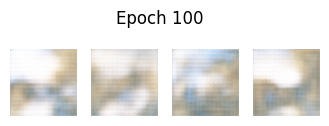

Epoch 101, Generator Loss: 0.5775, Discriminator Loss: 1.5034, Time: 1.41 sec
Epoch 102, Generator Loss: 0.4221, Discriminator Loss: 1.8604, Time: 1.43 sec
Epoch 103, Generator Loss: 1.0967, Discriminator Loss: 1.2292, Time: 1.46 sec
Epoch 104, Generator Loss: 0.7371, Discriminator Loss: 1.0952, Time: 1.43 sec
Epoch 105, Generator Loss: 1.1200, Discriminator Loss: 0.8670, Time: 1.43 sec
Epoch 106, Generator Loss: 0.8325, Discriminator Loss: 1.1669, Time: 1.43 sec
Epoch 107, Generator Loss: 2.4222, Discriminator Loss: 1.1093, Time: 1.43 sec
Epoch 108, Generator Loss: 0.9426, Discriminator Loss: 1.0191, Time: 1.43 sec
Epoch 109, Generator Loss: 0.7215, Discriminator Loss: 1.2724, Time: 1.43 sec
Epoch 110, Generator Loss: 2.6971, Discriminator Loss: 3.2974, Time: 1.42 sec
Epoch 111, Generator Loss: 0.9971, Discriminator Loss: 1.1212, Time: 1.43 sec
Epoch 112, Generator Loss: 0.4620, Discriminator Loss: 1.3890, Time: 1.42 sec
Epoch 113, Generator Loss: 3.3513, Discriminator Loss: 4.1617, T

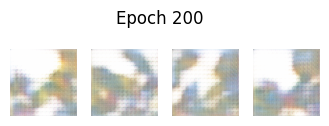

Epoch 201, Generator Loss: 0.3013, Discriminator Loss: 1.5718, Time: 1.42 sec
Epoch 202, Generator Loss: 0.9237, Discriminator Loss: 1.0793, Time: 1.45 sec
Epoch 203, Generator Loss: 0.4893, Discriminator Loss: 1.2847, Time: 1.43 sec
Epoch 204, Generator Loss: 0.8059, Discriminator Loss: 1.0379, Time: 1.46 sec
Epoch 205, Generator Loss: 0.5849, Discriminator Loss: 1.1586, Time: 1.44 sec
Epoch 206, Generator Loss: 1.1143, Discriminator Loss: 0.8853, Time: 1.40 sec
Epoch 207, Generator Loss: 3.1014, Discriminator Loss: 0.9301, Time: 1.44 sec
Epoch 208, Generator Loss: 3.3078, Discriminator Loss: 0.6813, Time: 1.43 sec
Epoch 209, Generator Loss: 1.2491, Discriminator Loss: 1.0054, Time: 1.44 sec
Epoch 210, Generator Loss: 1.4137, Discriminator Loss: 0.7280, Time: 1.45 sec
Epoch 211, Generator Loss: 0.0347, Discriminator Loss: 3.4902, Time: 1.44 sec
Epoch 212, Generator Loss: 1.3092, Discriminator Loss: 1.1893, Time: 1.45 sec
Epoch 213, Generator Loss: 0.0294, Discriminator Loss: 3.6389, T

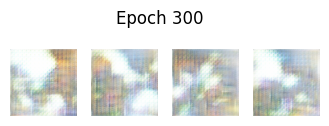

Epoch 301, Generator Loss: 1.5982, Discriminator Loss: 0.7241, Time: 1.43 sec
Epoch 302, Generator Loss: 1.1431, Discriminator Loss: 0.7946, Time: 1.44 sec
Epoch 303, Generator Loss: 1.6238, Discriminator Loss: 0.8406, Time: 1.42 sec
Epoch 304, Generator Loss: 1.5587, Discriminator Loss: 1.2118, Time: 1.45 sec
Epoch 305, Generator Loss: 1.8450, Discriminator Loss: 0.7302, Time: 1.45 sec
Epoch 306, Generator Loss: 0.6334, Discriminator Loss: 0.9805, Time: 1.41 sec
Epoch 307, Generator Loss: 1.0621, Discriminator Loss: 0.9997, Time: 1.43 sec
Epoch 308, Generator Loss: 2.5293, Discriminator Loss: 0.4680, Time: 1.44 sec
Epoch 309, Generator Loss: 1.1510, Discriminator Loss: 0.6209, Time: 1.45 sec
Epoch 310, Generator Loss: 1.8455, Discriminator Loss: 0.5528, Time: 1.44 sec
Epoch 311, Generator Loss: 1.4064, Discriminator Loss: 0.6931, Time: 1.49 sec
Epoch 312, Generator Loss: 2.0411, Discriminator Loss: 0.5889, Time: 1.46 sec
Epoch 313, Generator Loss: 3.8932, Discriminator Loss: 0.7051, T

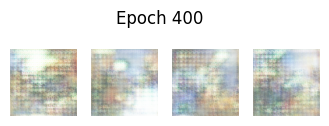

Epoch 401, Generator Loss: 4.3098, Discriminator Loss: 0.9325, Time: 1.45 sec
Epoch 402, Generator Loss: 1.4729, Discriminator Loss: 0.6038, Time: 1.45 sec
Epoch 403, Generator Loss: 0.5895, Discriminator Loss: 1.0723, Time: 1.47 sec
Epoch 404, Generator Loss: 1.5385, Discriminator Loss: 0.6223, Time: 1.49 sec
Epoch 405, Generator Loss: 0.4573, Discriminator Loss: 1.1555, Time: 1.49 sec
Epoch 406, Generator Loss: 1.4780, Discriminator Loss: 0.7937, Time: 1.46 sec
Epoch 407, Generator Loss: 3.9680, Discriminator Loss: 0.9710, Time: 1.46 sec
Epoch 408, Generator Loss: 1.4261, Discriminator Loss: 0.6725, Time: 1.41 sec
Epoch 409, Generator Loss: 1.0664, Discriminator Loss: 1.0665, Time: 1.45 sec
Epoch 410, Generator Loss: 1.6297, Discriminator Loss: 0.4905, Time: 1.46 sec
Epoch 411, Generator Loss: 1.3243, Discriminator Loss: 0.8922, Time: 1.43 sec
Epoch 412, Generator Loss: 1.1588, Discriminator Loss: 0.8497, Time: 1.47 sec
Epoch 413, Generator Loss: 1.3988, Discriminator Loss: 0.9959, T

In [ ]:
import time
import matplotlib.pyplot as plt

# Set training parameters
EPOCHS = 3000
NUM_EXAMPLES_TO_GENERATE = 4
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

# Prepare the training dataset using Monet paintings (real data for our GAN)
monet_dataset_train = monet_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        # Scale images from [-1, 1] to [0, 1] if tanh is used
        plt.imshow((predictions[i] + 1.0) / 2.0)
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch+1}')
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
        
        print(f'Epoch {epoch+1}, Generator Loss: {gen_loss.numpy():.4f}, Discriminator Loss: {disc_loss.numpy():.4f}, Time: {time.time() - start:.2f} sec')
        
        # Visualize every 100 epochs only
        if (epoch + 1) % 100 == 0:
            generate_and_save_images(generator, epoch, seed)

# Start training
train(monet_dataset_train, EPOCHS)

In [ ]:
import os
from tensorflow.keras.preprocessing.image import save_img

# Directory to save generated images
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

def generate_and_save_final_images(model, num_images, noise_dim, output_dir):
    num_batches = num_images // BATCH_SIZE
    remaining_images = num_images % BATCH_SIZE
    total_saved = 0

    for batch in range(num_batches):
        noise = tf.random.normal([BATCH_SIZE, noise_dim])
        generated_images = model(noise, training=False)
        # Scale images from [-1,1] to [0,1] if tanh was used in generator
        generated_images = (generated_images + 1.0) / 2.0

        for i in range(BATCH_SIZE):
            img = generated_images[i].numpy()
            save_img(os.path.join(output_dir, f"generated_{total_saved + 1:05d}.png"), img)
            total_saved += 1

    if remaining_images:
        noise = tf.random.normal([remaining_images, noise_dim])
        generated_images = model(noise, training=False)
        generated_images = (generated_images + 1.0) / 2.0
        for i in range(remaining_images):
            img = generated_images[i].numpy()
            save_img(os.path.join(output_dir, f"generated_{total_saved + 1:05d}.png"), img)
            total_saved += 1

    print(f"Total generated images saved: {total_saved}")

# Generate and save 7,000 images (adjust number if needed)
NUM_FINAL_IMAGES = 7000
generate_and_save_final_images(generator, NUM_FINAL_IMAGES, NOISE_DIM, output_dir)
